In [64]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from copy import deepcopy

In [65]:
resultsPath = os.path.join('.', "results/nudge_intermediate/")
resultsList = [os.path.join('.', "results/nudge_intermediate_new/")]

# last col median of all alphas
# last row median of all mus
# last cell global median

col = [0, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0, "mu median"]
row = []
# row = [1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-15, 1e-17, 1e-19, 1e-21, 1e-23, 1e-30]
# row.extend([6.92308e-10, 9.230770000000001e-10, 8.02e-16, 5.384619999999999e-10, 4.060000000000001e-16, 3.846159999999999e-10, 7.69239999999998e-11, 2.0800000000000003e-16, 7.692309999999999e-10, 6.040000000000001e-16, 1.5384699999999991e-10, 4.6153899999999993e-10, 2.3076999999999992e-10, 8.461540000000001e-10, 6.153849999999999e-10, 3.076929999999999e-10])
# row.sort(reverse=True)
# row.append("alpha median")

In [66]:
template = pd.DataFrame(np.nan, index=row, columns=col, dtype=float)

iDlgLossTable = template.copy()
iDlgMseTable = template.copy()

DlgLossTable = template.copy()
DlgMseTable = template.copy()

tables = {
    "iDlgLoss": iDlgLossTable,
    "iDlgMse": iDlgMseTable,
    "DlgLoss": DlgLossTable,
    "DlgMse": DlgMseTable
}

In [67]:
for resultsPath in resultsList:
    for folder in os.listdir(resultsPath):
        if os.path.isfile(os.path.join(resultsPath, folder)):
            continue
        parameters = folder.split('_')
        mu = float(parameters[0])
        alpha = float(parameters[1])
        results = os.path.join(resultsPath, folder, "results.csv")
        df = pd.read_csv(results)

        iDlgLossTable.loc[mu, alpha] = float(f"{df.iloc[:, 3].median():.4e}")
        iDlgMseTable.loc[mu, alpha] = float(f"{df.iloc[:, 4].median():.4e}")

        DlgLossTable.loc[mu, alpha] = float(f"{df.iloc[:, 1].median():.4e}")
        DlgMseTable.loc[mu, alpha] = float(f"{df.iloc[:, 2].median():.4e}")
    iDlgLossTable.sort_index(ascending=False, inplace=True)
    iDlgMseTable.sort_index(ascending=False, inplace=True)
    DlgLossTable.sort_index(ascending=False, inplace=True)
    DlgMseTable.sort_index(ascending=False, inplace=True)


row.append("alpha median")

In [68]:
for name, table in tables.items():
    # table = pd.DataFrame(table)

    table["mu median"] = table.median(axis=1).apply(lambda x: float(f"{x:.4e}"))

    # pMedians = table.median(axis=0)

    table.loc["alpha median"] =  table.median(axis=0).apply(lambda x: float(f"{x:.4e}"))

    table.loc["alpha median", "mu median"] =  float(f"{table.iloc[:-1, :-1].stack().median():.4e}")

    tables[name] = table

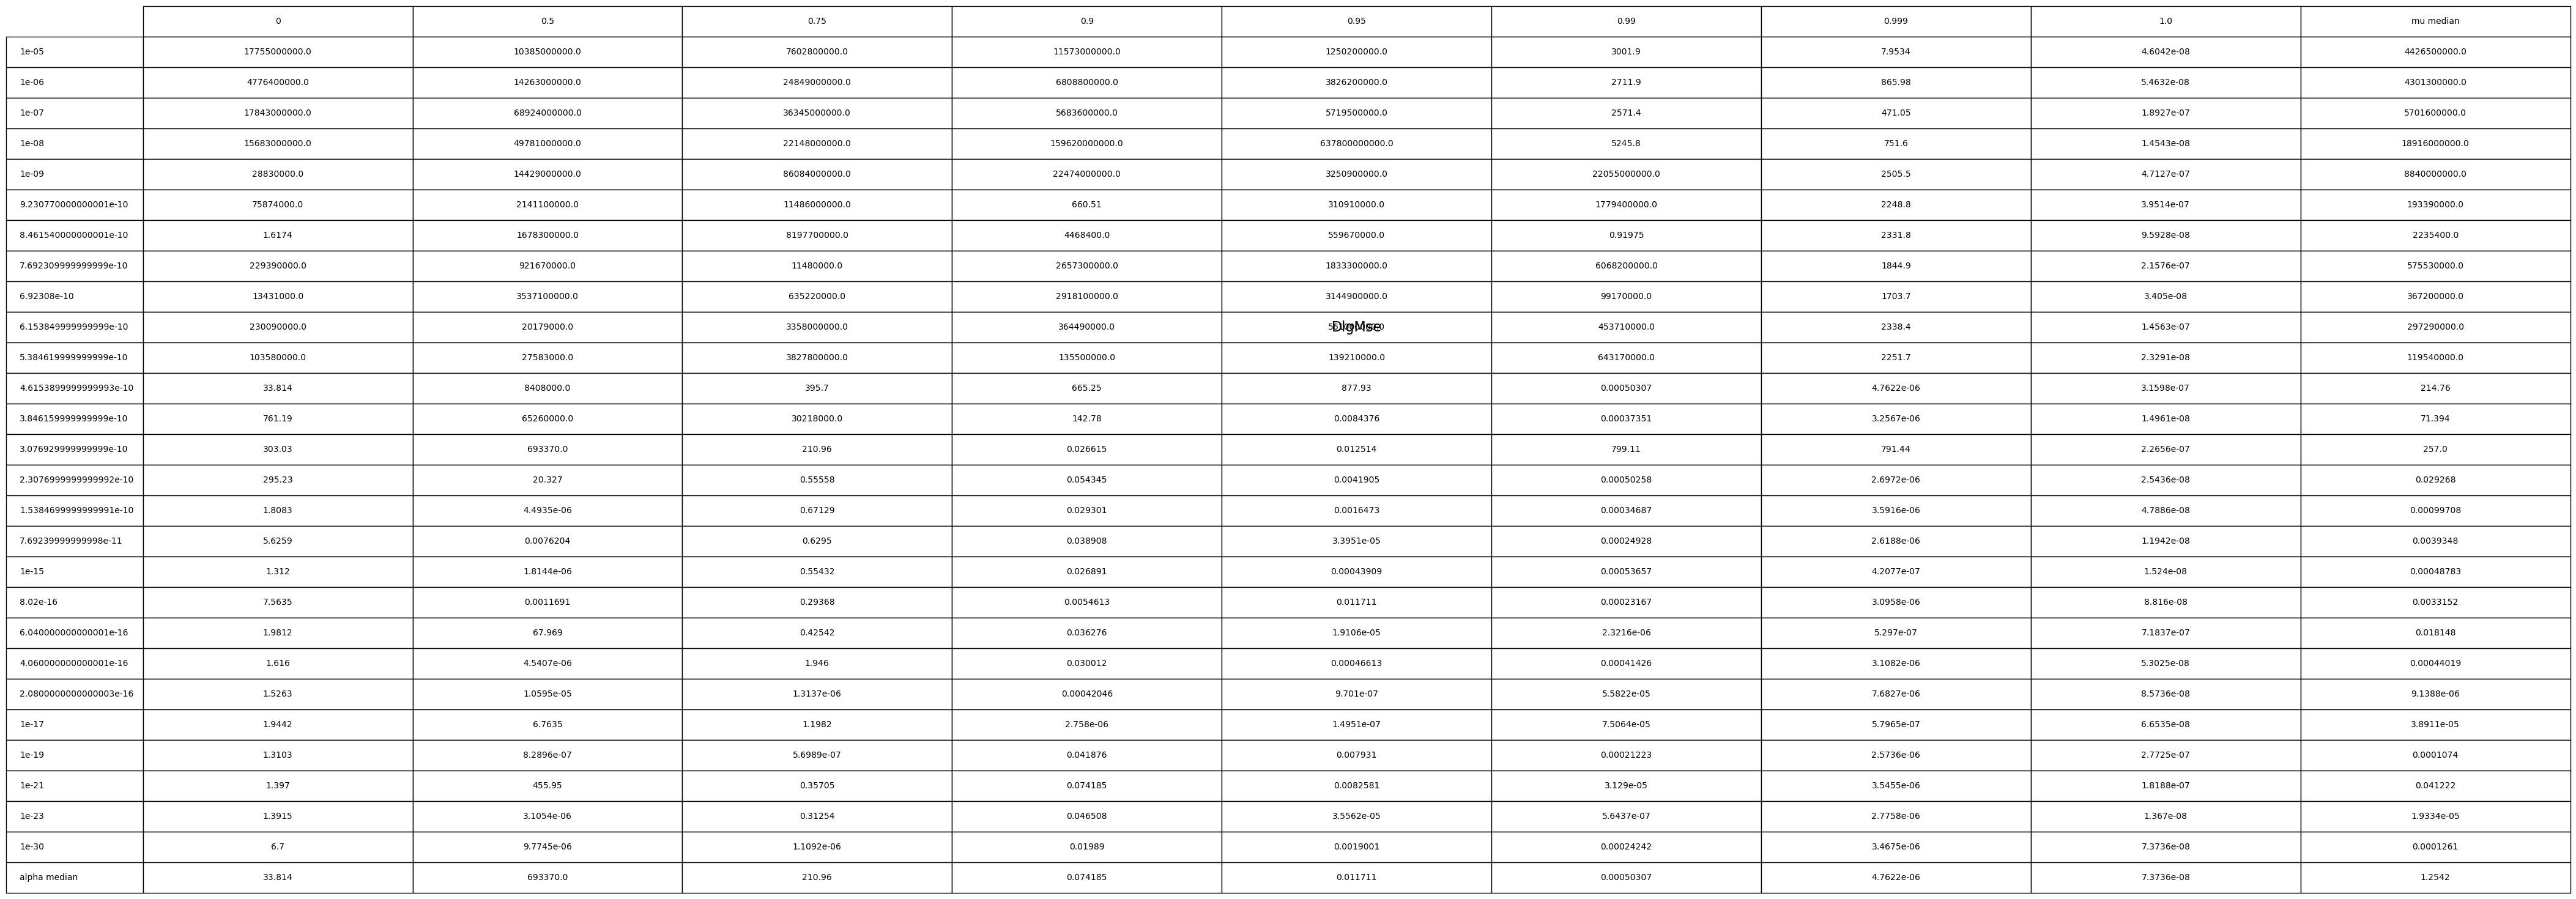

In [ ]:
plot = "DlgLoss"

fig, ax = plt.subplots()
ax.axis("off")
table = ax.table(
    cellText=tables[plot],
    cellLoc="center",
    loc="center"
)
plt.title(plot, fontsize=16)

table.scale(8, 3)


plt.show()

In [70]:
df = pd.DataFrame(tables[plot])
# csvPath = os.path.join(resultsPath, f"{plot}.csv")
csvPath = f"{plot}.csv"
df.to_csv(csvPath, index=True, header=True)